# PARCIAL. PARTE PRACTICA

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from rapidfuzz import process, fuzz, utils
from rapidfuzz.distance import Jaro, JaroWinkler

## EJERCICIO 1

In [31]:
pacientes = pd.read_csv("pacientes_clinica.csv")
pacientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_paciente        184 non-null    str    
 1   edad               184 non-null    int64  
 2   imc                184 non-null    float64
 3   glucosa            184 non-null    float64
 4   actividad_fisica   184 non-null    int64  
 5   tabaquismo         184 non-null    int64  
 6   presion_sistolica  184 non-null    float64
dtypes: float64(3), int64(3), str(1)
memory usage: 11.4 KB


## EJERCICIO 2

/tmp/ipykernel_12923/1715934963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(fumador, palette='viridis')
/tmp/ipykernel_12923/1715934963.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


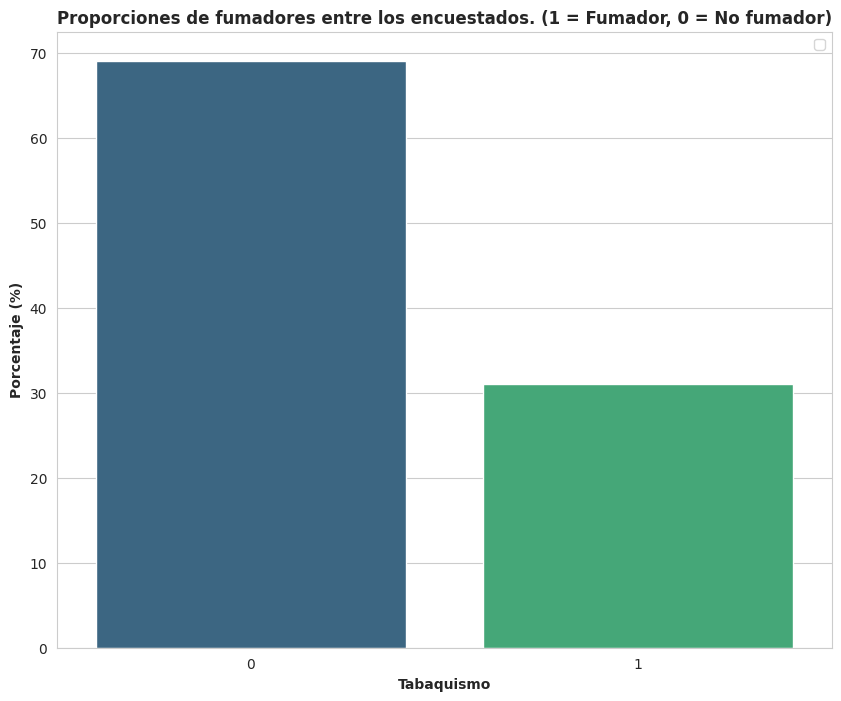

tabaquismo
0    69.021739
1    30.978261
Name: proportion, dtype: float64


In [32]:
# Vamos a construir un barplot para visualizar correctamente estos datos
plt.figure(figsize=(10,8))

fumador = pacientes.value_counts('tabaquismo', normalize=True) * 100
    
sns.set_style('whitegrid')
sns.barplot(fumador, palette='viridis')
plt.title('Proporciones de fumadores entre los encuestados. (1 = Fumador, 0 = No fumador)', fontweight='bold')
plt.xlabel('Tabaquismo', fontweight='bold')
plt.ylabel('Porcentaje (%)', fontweight='bold')
plt.legend()
plt.show()

# Para ver los porcentajes
print(fumador)

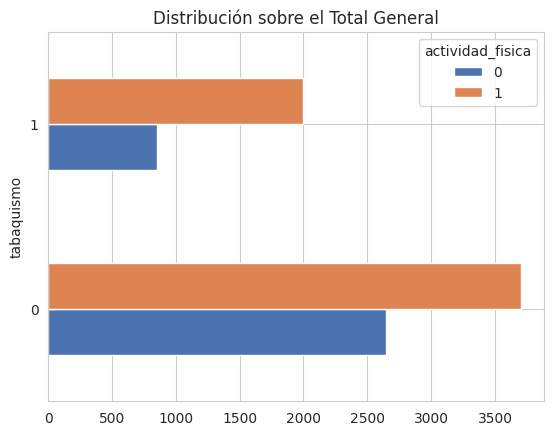

In [33]:
# Tabla de doble entrada
tabla_total = pd.crosstab(pacientes['tabaquismo'], pacientes['actividad_fisica'])

# Normalizamos por el total general (n)
tabla_total_porc = (tabla_total / len(tabla_total)) * 100

tabla_total_porc.plot.barh(stacked=False, color=sns.color_palette('deep'))
plt.title('Distribución sobre el Total General')
plt.show()

## EJERCICIO 3

a)

In [ ]:
# Utilizaremos la similaridad de Jaro-Winkler (redondeada a 4 decimales)

#primer ID
sim_jw_a1 = round(JaroWinkler.similarity('CL-0A81', 'CL-0481'), 4)
print("Score para Candidato 1A:", sim_jw_a1)

sim_jw_a2 = round(JaroWinkler.similarity('CL-0A81', 'CL-0824'), 4)
print("Score para Candidato 1B:", sim_jw_a2)

#segundo ID
sim_jw_b1 = round(JaroWinkler.similarity('CI-1B27', 'CL-1327'), 4)
print("Score para Candidato 2A:",sim_jw_b1)

sim_jw_b2 = round(JaroWinkler.similarity('CI-1B27', 'CL-2137'), 4)
print("Score para Candidato 2B:", sim_jw_b2)

Score para Candidato A: 0.9429
Score para Candidato B: 0.8857
Score para Candidato A: 0.8286
Score para Candidato B: 0.7686


b)

    Notamos que, para el primer ID, tenemos que el candidato A tiene un score de 0.94, por lo tanto conincide con el registro. Los demas no llegan a la puntuacion requerida

## EJERCICIO 4

a)

In [34]:
# Creamos el primer modelo con todas las variables predictoras posibles
modelo_presion = smf.ols('presion_sistolica ~ edad + imc + glucosa + actividad_fisica + tabaquismo', data=pacientes).fit()
print(modelo_presion.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     109.0
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.85e-52
Time:                        19:21:38   Log-Likelihood:                -598.64
No. Observations:                 184   AIC:                             1209.
Df Residuals:                     178   BIC:                             1229.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           49.9685      4.225  

    De la anterior salida podemos ver que, la variable 'actividad_fisica' tiene un p-value > 0.05 (esto es mas que lo que se nos indico con un nivel de significancia del 5%), por lo tanto esta variable puede ser descartada ya que no aporta al ajuste del modelo.

b)

In [35]:
# Ajustamos el modelo nuevo sin la variable de actividad fisica
modelo_presion_ajustado = smf.ols('presion_sistolica ~ edad + imc + glucosa + tabaquismo', data=pacientes).fit()
print(modelo_presion_ajustado.summary())

                            OLS Regression Results                            
Dep. Variable:      presion_sistolica   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     136.8
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           2.57e-53
Time:                        19:21:38   Log-Likelihood:                -598.77
No. Observations:                 184   AIC:                             1208.
Df Residuals:                     179   BIC:                             1224.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.8068      4.203     11.851      0.0

    Notamos una leve mejoria en el valor del Adj. R-squared, lo que nos indica que el eliminar la variable de actividad fisica para el ajuste del modelo, fue un acierto.

c)

### Ecuacion del modelo ajustado: 

$$presion\_sistolica = 49.8 + 0.52 \cdot edad + 1.38 \cdot imc + 0.21 \cdot glucosa + 7.03 \cdot tabaquismo$$

d)

In [36]:
# Para predecir con los datos que se nos piden, debemos antes empaquetarlos en un DF para poder pasarselo al metodo .predict
datos_nuevo_paciente = pd.DataFrame({
    'edad': [50],
    'imc': [28.5],
    'glucosa' : [102],
    'tabaquismo' : [0]
})

# Le pedimos al modelo ajustado que haga la predicción
prediccion_presion = modelo_presion_ajustado.predict(datos_nuevo_paciente)

# Imprimimos el resultado formateado
# prediccion_presion es una Serie, así que extraemos el primer valor con .iloc[0]
print(f"La presion arterial sistolica de este paciente es de: {prediccion_presion.iloc[0]:.2f} mm Hg")

La presion arterial sistolica de este paciente es de: 136.67 mm Hg


e)

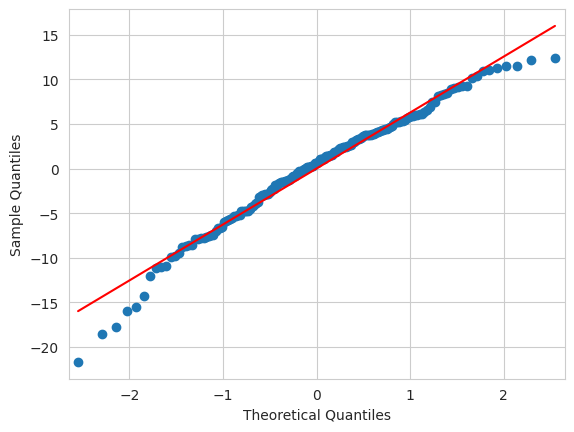

In [37]:
# Prueba de Normalidad

# Graficamos el Normal Q-Q Plot
sm.qqplot(modelo_presion_ajustado.resid, line='s')
plt.show()

    Aqui tenemos una Red Flag, ya que este grafico nos confirma que los residuos no parecieran seguir una distribucion normal. En el summary lo podemos ver en los valores de Prob(JB) o Prob(Omnibus) (parametros que nos indican la normalidad), donde estos son menores que 0.05. Cuando para poder pasar esta prueba deben ser mayores a dicho valor.

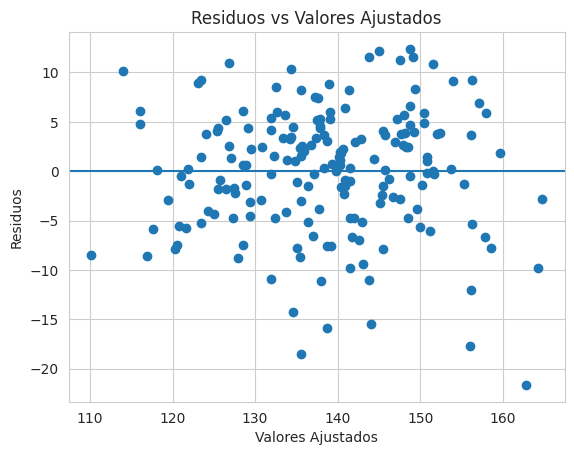

In [38]:
# Prueba de Homocedasticidad

residuals = modelo_presion_ajustado.resid
fitted = modelo_presion_ajustado.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(y=0)
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Ajustados")
plt.show()

    Aquí no observamos ningún patrón por lo que se consideran residuos homocedásticos.